<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Intermediate_NLP_Long_Short_Term_Memory_(LSTM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
google_wiki_words_tensorflow2_250_1_path = kagglehub.model_download('google/wiki-words/TensorFlow2/250/1')

print('Data source import complete.')



  0%|          | 0.00/8.27M [00:00<?, ?B/s]



100%|██████████| 23.0k/23.0k [00:00<00:00, 2.89MB/s]




100%|██████████| 218/218 [00:00<00:00, 456kB/s]

100%|██████████| 8.27M/8.27M [00:00<00:00, 81.1MB/s]



  0%|          | 0.00/963M [00:00<?, ?B/s]
  1%|          | 9.00M/963M [00:00<00:11, 86.2MB/s]
  2%|▏         | 19.0M/963M [00:00<00:20, 48.0MB/s]
  4%|▎         | 36.0M/963M [00:00<00:11, 85.3MB/s]
  5%|▌         | 51.0M/963M [00:00<00:09, 106MB/s] 
  7%|▋         | 67.0M/963M [00:00<00:09, 100MB/s]
  9%|▉         | 85.0M/963M [00:00<00:07, 121MB/s]
 11%|█         | 102M/963M [00:00<00:06, 135MB/s] 
 12%|█▏        | 117M/963M [00:01<00:06, 140MB/s]
 14%|█▎        | 132M/963M [00:01<00:06, 138MB/s]
 15%|█▌        | 149M/963M [00:01<00:05, 148MB/s]
 17%|█▋        | 166M/963M [00:01<00:05, 155MB/s]
 19%|█▉        | 183M/963M [00:01<00:05, 152MB/s]
 21%|██        | 199M/963M [00:01<00:05, 154MB/s]
 22%|██▏       | 214M/963M [00:01<00:05, 155MB/s]
 24%|██▍       | 230M/963M [00:01<00:04, 158MB/s]
 26%|██▌       | 247M/963M [00:01<00:04, 164MB/s]
 27%|██▋       | 263M/963M [00:02<00:04, 161MB/s]
 29%|██▉       | 279M/963M [00:02<00:04, 154MB/s]
 31%|███       | 294M/963M [00:02<00:05, 139

Data source import complete.


# Intermediate NLP: Long Short-Term Memory (LSTM) Networks

Welcome to Module 4! In the previous section **[(Module 3)](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-recurrent-neural-networks)**, we built a Simple Recurrent Neural Network (RNN) to process sequences of text. While Simple RNNs are theoretically brilliant, they suffer from a massive flaw in practice when dealing with long paragraphs of text.

In this lesson, we will uncover why Simple RNNs fail, and how **Long Short-Term Memory (LSTM)** networks solve this problem to become one of the most powerful tools in Natural Language Processing.

## Introduction

Imagine reading a long movie review: *"I grew up in France... [50 words later] ...and so I speak fluent ____."*
You instantly know the missing word is "French" because you remember the context from the very beginning of the sentence.

Simple RNNs struggle with this. Because an RNN calculates its hidden state sequentially, the mathematical gradient used to update the network's weights during training is repeatedly multiplied by the same numbers over and over again across time steps.

If these numbers are smaller than 1, multiplying them repeatedly causes the gradient to shrink exponentially until it vanishes completely. This is called the **Vanishing Gradient Problem**. By the time the Simple RNN reaches the end of a long sentence, it has completely "forgotten" the beginning! (Note: If the numbers are larger than 1, the gradient explodes to infinity, known as the *Exploding Gradient Problem*, but vanishing is much more common in text).

To fix this, LSTMs introduce a new continuous memory line called the **Cell State (Ct)**. Think of the Cell State as a conveyor belt that runs straight down the entire sequence. The LSTM can explicitly choose to add new information to this conveyor belt, or forget old information, using distinct mathematical **Gates**.

## The Mathematics of LSTM Gates

An LSTM utilizes three primary gates to control the flow of information. They use the Sigmoid activation function ($\sigma$), which outputs a number between $0$ (completely forget/block) and $1$ (completely remember/pass).

**1. The Forget Gate ($f_t$)**
Decides what information from the past we should throw away.
$$ f_t = \sigma(W_f \cdot [H_{t-1}, X_t] + b_f) $$

**2. The Input Gate ($i_t$) and Candidate Memory ($\tilde{C}_t$)**
Decides what *new* information from the current word ($X_t$) is worth adding to the cell state.
$$ i_t = \sigma(W_i \cdot [H_{t-1}, X_t] + b_i) $$
$$ \tilde{C}_t = \tanh(W_C \cdot [H_{t-1}, X_t] + b_C) $$

**3. Updating the Cell State ($C_t$)**
We multiply the old state by the Forget Gate, and add the new information from the Input Gate. This creates the new "conveyor belt" memory!
$$ C_t = f_t * C_{t-1} + i_t * \tilde{C}_t $$

**4. The Output Gate ($o_t$) and New Hidden State ($H_t$)**
Decides what parts of the Cell State we want to output to the next layer (and to the next time step) as the new Hidden State.
$$ o_t = \sigma(W_o \cdot [H_{t-1}, X_t] + b_o) $$
$$ H_t = o_t * \tanh(C_t) $$

Now, let's map these mathematical equations to a visual way to show a single LSTM cell at time step $t$.






At the top, the cell receives the current word ($X_t$) and the hidden state from the previous step ($H_{t-1}$). These are concatenated and fed into the various gates. Notice the line flowing straight from $C_{t-1}$ to $C_t$. This is the cell state. It runs through the top of the diagram with only minor linear interactions (the `*` and `+` nodes), allowing gradients to flow backwards smoothly without vanishing! The Forget Gate outputs a percentage that multiplies (`*`) against the old cell state ($C_{t-1}$). Input Gate multiplies (`*`) with the Candidate Memory to decide what new information to add (`+`) to the conveyor belt. Finally, the updated conveyor belt ($C_t$) is squashed through a `tanh` node and multiplied (`*`) by the Output Gate to produce the new Hidden State ($H_t$), which is passed to the next cell.

## Re-initializing our Data Environment

Just like in the previous sections, we need to load our raw movie reviews and convert them into mathematical vectors using the pre-trained **Wiki-words** model from TensorFlow Hub. Because our neural networks require uniform input shapes, we will apply zero-padding to make all sentences match the length of the longest review.

In [2]:
import pandas as pd
import numpy as np
import tensorflow_hub as hub
import random
import os
import tensorflow as tf
import kagglehub

def set_deterministic_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_deterministic_seed(42)

# 1. Load the Data
dataset_path = kagglehub.dataset_download("kinchittrivedi/sentiment-analysis-movie-reviews")
positive_file_path = os.path.join(dataset_path, 'positive.txt')
negative_file_path = os.path.join(dataset_path, 'negative.txt')

with open(positive_file_path, "r", encoding="latin-1") as f:
    positives = [line.strip() for line in f]
with open(negative_file_path, "r", encoding="latin-1") as f:
    negatives = [line.strip() for line in f]

df = pd.DataFrame({
    'text': positives + negatives,
    'label': [1] * len(positives) + [0] * len(negatives)
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Download the model using kagglehub for better performance on Kaggle
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
# Load the 250-dimensional Wiki-words embedding model from tensorFlow hub
embed = hub.load(model_path)

# 3. Define the Preprocessing Helper Functions
def get_max_length(df):
    max_length = 0
    for row in df['text']:
        tokens = row.split(" ")
        if len(tokens) > max_length:
            max_length = len(tokens)
    return max_length

def get_word2vec_enc(texts):
    encoded_texts = []
    for text in texts:
        tokens = text.split(" ")
        word2vec_embedding = embed(tokens)
        encoded_texts.append(word2vec_embedding)
    return encoded_texts

def get_padded_encoded_texts(encoded_texts, max_len):
    padded_texts_encoding = []
    for enc_text in encoded_texts:
        zero_padding_cnt = max_len - enc_text.shape[0]
        pad = np.zeros((1, 250))
        for i in range(zero_padding_cnt):
            enc_text = np.concatenate((pad, enc_text), axis=0)
        padded_texts_encoding.append(enc_text)
    return padded_texts_encoding

def preprocess(df, max_len):
    texts = df['text'].tolist()
    encoded_texts = get_word2vec_enc(texts)
    padded_encoded_texts = get_padded_encoded_texts(encoded_texts, max_len)

    X = np.array(padded_encoded_texts)
    Y = np.array(df['label'].tolist())
    return X, Y

# 4. Execute the Pipeline
max_length = get_max_length(df)
print(f"The maximum sequence length in the dataset is: {max_length}")

# Note: This step processes the embeddings and takes a moment
X, Y = preprocess(df, max_length)

print(f"Shape of X (Training Data): {X.shape}")
print(f"Shape of Y (Labels): {Y.shape}")

100%|██████████| 1.07M/1.07M [00:00<00:00, 66.5MB/s]

Extracting files...


The maximum sequence length in the dataset is: 100
Shape of X (Training Data): (5000, 100, 250)
Shape of Y (Labels): (5000,)


This is standard boilerplate to prepare our inputs. We load the raw movie reviews, shuffle them, and convert the raw text into uniform numerical sequences of length 50 using `TextVectorization`. We then download the 100-dimensional GloVe model and build an `embedding_matrix` so our neural network can utilize these pre-trained meaning-based features instead of starting from scratch.


## Building an LSTM Model

In the previous section, our SimpleRNN struggled with overfitting. To demonstrate the power of LSTMs, let's start creating a very simple model to solve the problem.

In [4]:
from tensorflow.keras import layers, Model

# 1. Define the Input layer
inputs = layers.Input(shape=(max_length, 250))

# 2. Add the LSTM layer with VERY low capacity (deliberate underfitting)
x = layers.LSTM(units=4)(inputs)

# 3. Add the final Dense classification layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Construct the Model
lstm_model = Model(inputs=inputs, outputs=outputs, name="Underfitting_LSTM")
lstm_model.summary()

Model: "Underfitting_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 250)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 4)              │         4,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,085 (15.96 KB)

 Trainable params: 4,085 (15.96 KB)

 Non-trainable params: 0 (0.00 B)

**Code Explanation:**
* `layers.LSTM(units=4)`: This single line of code implements all the complex math and gates we discussed above! The `units=4` means both our Hidden State ($H_t$) and our Cell State ($C_t$) will be vectors containing 4 numbers.
* Notice how the number of parameters in the model summary is much higher than a Simple RNN. This is because the LSTM has 4 sets of mathematical weights (for the Forget, Input, Output gates, and Candidate Memory) instead of just 1!

We will train this model and immediately plot the learning curves to analyze its performance.

Starting training for the Model...


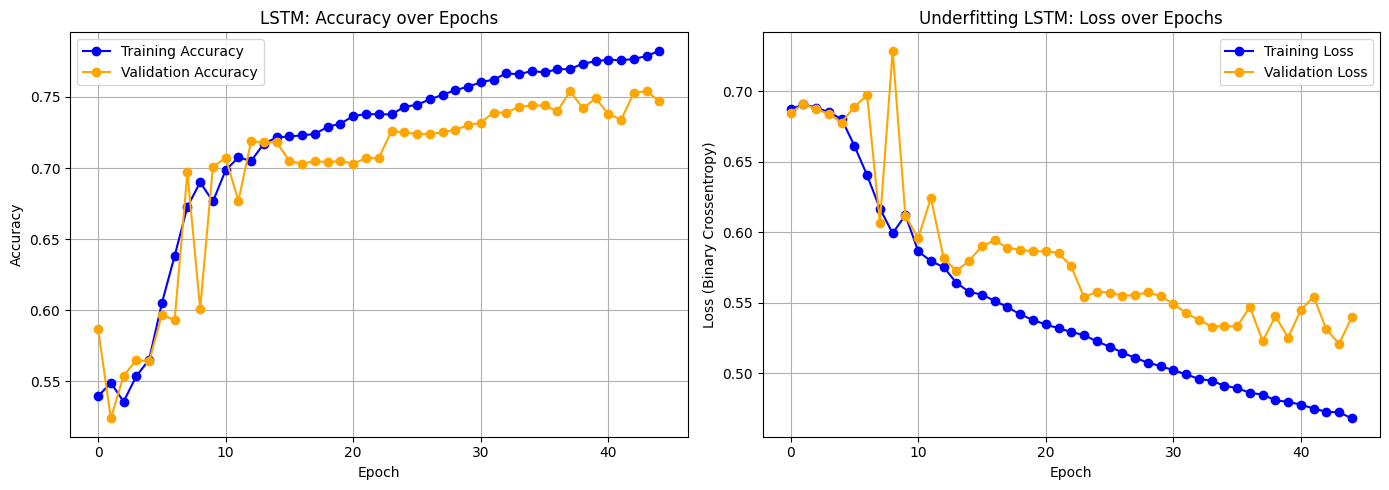

In [5]:
import matplotlib.pyplot as plt

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
print("Starting training for the Model...")
history = lstm_model.fit(
    X,
    Y,
    epochs=45,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Plot Accuracy and Loss over Epochs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('LSTM: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Underfitting LSTM: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Look at the plots above. Our 4-unit LSTM *does* learn, reaching about 75% validation accuracy, but it plateaus quickly. Here are why:
* **Limited Capacity:** Because we only gave the LSTM 4 units (a tiny memory cell capacity), the network fundamentally lacks the mathematical flexibility to model deeper, complex nuances of language.
* **Slight Overfitting:** Notice how the training accuracy continues to slowly climb toward 79% while the validation accuracy flatlines, and validation loss starts to slowly inch upwards. Even with a tiny model, it eventually begins memorizing the training set!

To improve this, we need to increase the model's capacity to learn complex linguistic patterns, but simultaneously add **Regularization (Dropout)** to prevent it from extreme overfitting. Dropout prevents overfitting by randomly turning off a fraction of neurons during training, which forces the network to learn robust patterns rather than just memorizing the training data.

Let's step up the number of LSTM units to **32** and add dropout!

Starting training for the Regularized LSTM...


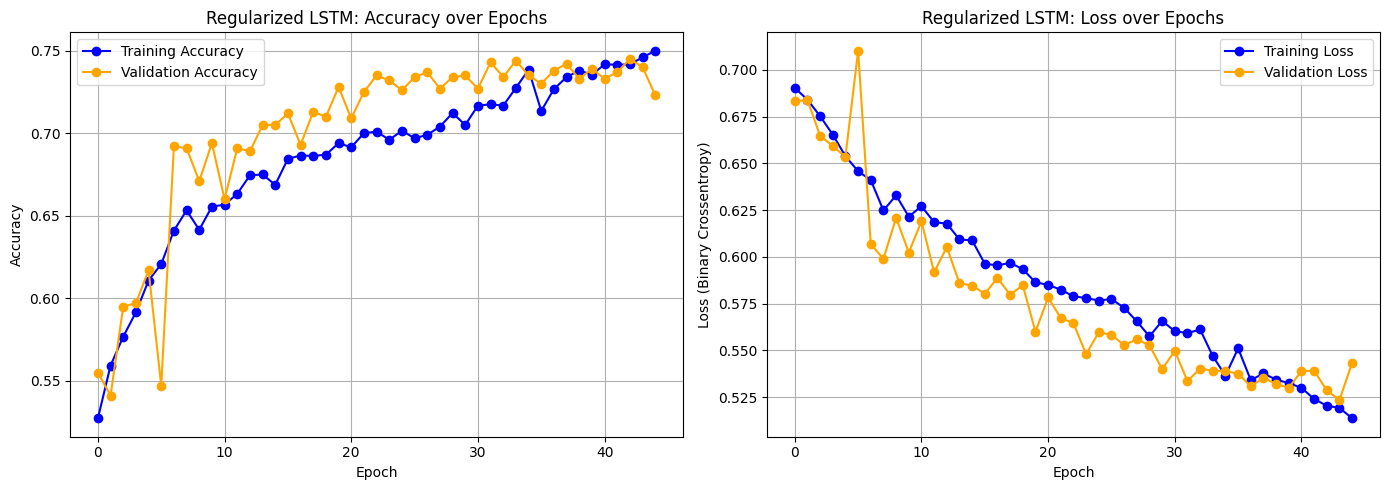

In [6]:
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# 1. Define Input
inputs = layers.Input(shape=(max_length, 250))

# 2. Add LSTM with tuned capacity and built-in Dropout
# Using 32 units gives it power to learn, and 30% dropout prevents overfitting
x = layers.LSTM(
    units=32,               # <-- CHANGED FROM 4 TO 32
    dropout=0.3,            # Drops 30% of the input connections
    recurrent_dropout=0.3   # Drops 30% of the recurrent memory connections
)(inputs)

# 3. Output Layer
outputs = layers.Dense(1, activation='sigmoid')(x)

# 4. Build and Compile
regularized_lstm_model = Model(inputs=inputs, outputs=outputs)

regularized_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Model
print("Starting training for the Regularized LSTM...")
regularized_history = regularized_lstm_model.fit(
    X, Y,
    epochs=45,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# 6. Plot the Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(regularized_history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
ax1.plot(regularized_history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Regularized LSTM: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(regularized_history.history['loss'], label='Training Loss', color='blue', marker='o')
ax2.plot(regularized_history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Regularized LSTM: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()



**Checking the Regularized LSTM:**
By increasing the capacity to 32 units and adding 30% dropout, our model performs noticeably better!
* **Higher Peak Accuracy:** The validation accuracy pushes higher (around 76.2%) and the validation loss drops lower than our 4-unit model.
* **Controlled Overfitting:** Notice how closely the training and validation lines track each other compared to typical deep learning models. The built-in `dropout` and `recurrent_dropout` parameters are doing their jobs beautifully, forcing the network to generalize rather than simply memorize the data.

## Conclusion & Next Steps

We explored how LSTMs solve the major weaknesses of Simple RNNs. By introducing a Cell State (our "conveyor belt") and a system of Gates (Forget, Input, Output), LSTMs prevent the Vanishing Gradient Problem. This allows the model to remember meaning-based context from the very beginning of a long sentence. We also learned how balancing model capacity with Regularization (Dropout) helps us train a model that generalizes well to unseen data.

While our current LSTM processes information sequentially from left to right (just like humans read), sometimes the most important context for understanding a word appears *later* in the sentence. For example, in the sentence "The bank of the river was muddy", the word "bank" means something entirely different than it would in "The bank approved my loan". Often, future words help us understand previous words!

To fix this, we can use Bidirectional LSTMs. A Bidirectional LSTM reads the sequence in both directions (left-to-right AND right-to-left) simultaneously, creating even richer and more powerful ways to represent the text. In **[Module 5: Bidirectional Long Short-Term Memory](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-bidirectional-long-short-term)**, we will build and train a Bidirectional LSTM to capture this two-way context and push our sentiment analysis performance even higher!
